In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2024/2024-03-19/mutant_moneyball.csv')
print(df.shape)

(26, 45)


In [1]:
from matplotlib import markers
print(markers.MarkerStyle.markers.keys())

dict_keys(['.', ',', 'o', 'v', '^', '<', '>', '1', '2', '3', '4', '8', 's', 'p', '*', 'h', 'H', '+', 'x', 'D', 'd', '|', '_', 'P', 'X', 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 'None', 'none', ' ', ''])


<br>

#### Reformat name in a more readable way

In [6]:
def format_name(s):
    if " " in s:
        return s
    formatted_string = ""
    for i, char in enumerate(s):
        if char.isupper() and i != 0:
            formatted_string += " " + char
        else:
            formatted_string += char
    if formatted_string:
        formatted_string = formatted_string[0].upper() + formatted_string[1:]
    
    return formatted_string

df['Member'] = df['Member'].apply(format_name)

for col in df.columns:
    if '$' in str(df[col][0]):
        df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)
    elif '%' in str(df[col][0]):
        df[col] = df[col].replace('[\%,]', '', regex=True).astype(float)

In [14]:
df.sample(5)

,Member,TotalIssues,TotalIssues60s,TotalIssues70s,TotalIssues80s,TotalIssues90s,totalIssueCheck,TotalValue_heritage,TotalValue60s_heritage,TotalValue70s_heritage,...,TotalValue80s_oStreet,TotalValue90s_oStreet,PPI60s_wiz,PPI70s_wiz,PPI80s_wiz,PPI90s_wiz,PPI60s_oStreet,PPI70s_oStreet,PPI80s_oStreet,PPI90s_oStreet
7,Ororo Munroe,190,0,36,121,33,190,227438,0,171050,...,2391.0,273.0,0.00,34.00,7.69,4.79,0.00,191.39,19.76,8.27
8,Kurt Wagner,120,0,36,84,0,120,221716,0,171050,...,2044.0,0.0,0.00,34.00,8.76,0.00,0.00,191.39,24.33,0.00
0,Warren Worthington,139,61,35,20,23,139,1108558,929056,154585,...,975.0,123.0,129.72,31.57,11.30,2.86,1117.38,210.29,48.75,5.35
3,Bobby Drake,123,62,35,6,20,123,1086749,929776,154585,...,137.0,108.0,128.27,31.57,8.00,3.10,1103.06,210.29,22.83,5.40
18,Alison Blaire,45,0,0,43,2,45,7268,0,0,...,567.0,14.0,0.00,0.00,6.65,5.50,0.00,0.00,13.19,7.00


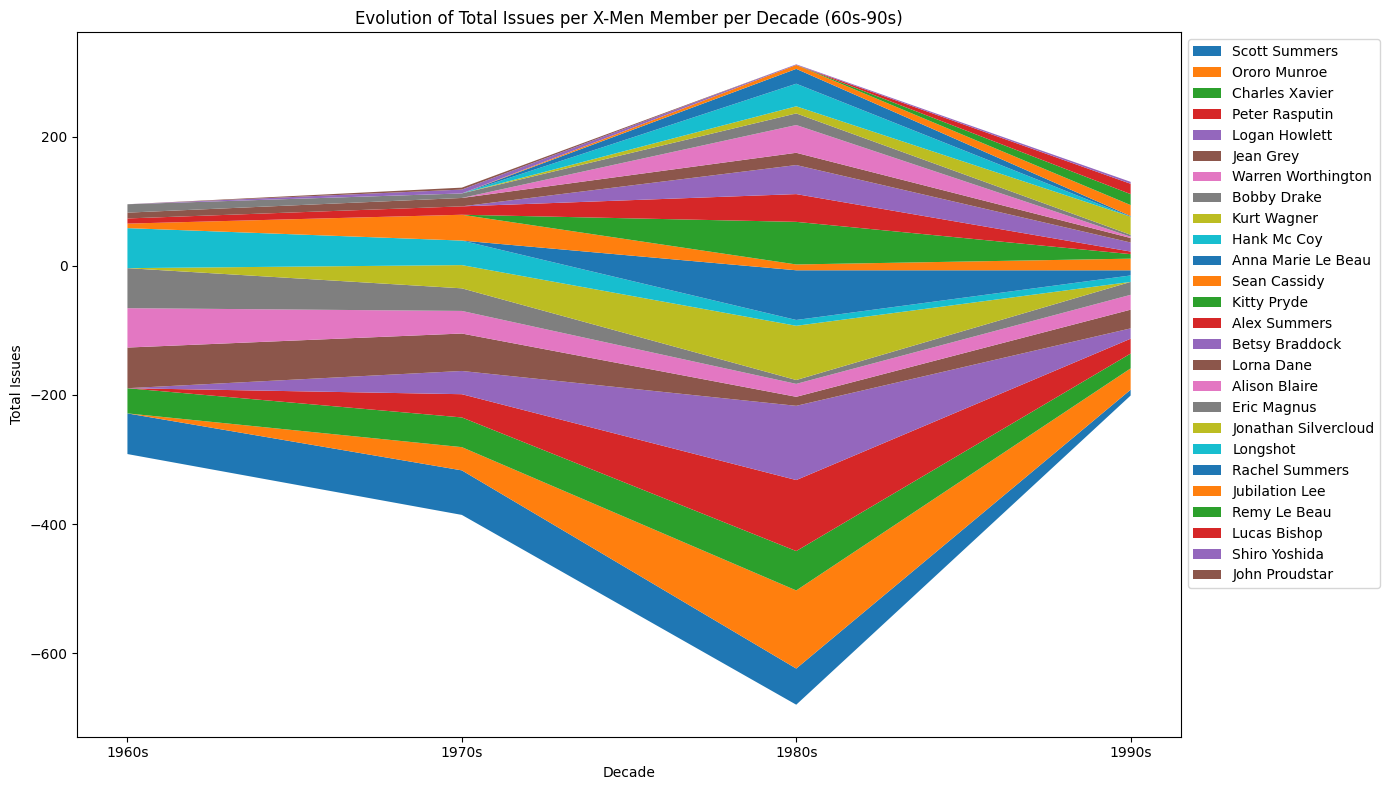

In [11]:
xmen_data = df.copy()

# Filter the dataset to include only the relevant columns for the streamgraph
xmen_decades = xmen_data[['Member', 'TotalIssues60s', 'TotalIssues70s', 'TotalIssues80s', 'TotalIssues90s']]

# Set index to Member for easier manipulation
xmen_decades.set_index('Member', inplace=True)

# Transpose the dataframe for plotting
xmen_decades_transposed = xmen_decades.T

# Prepare data for streamgraph
decades = ['1960s', '1970s', '1980s', '1990s']
members = xmen_decades_transposed.columns

# Convert the data into a list of lists, where each list corresponds to a member's issues over the decades
issues_list = xmen_decades_transposed.T.values.tolist()

# Plotting the streamgraph
plt.figure(figsize=(14, 8))
plt.stackplot(decades, issues_list, baseline='wiggle', labels=members)
plt.title('Evolution of Total Issues per X-Men Member per Decade (60s-90s)')
plt.ylabel('Total Issues')
plt.xlabel('Decade')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

# Show the plot
plt.show()

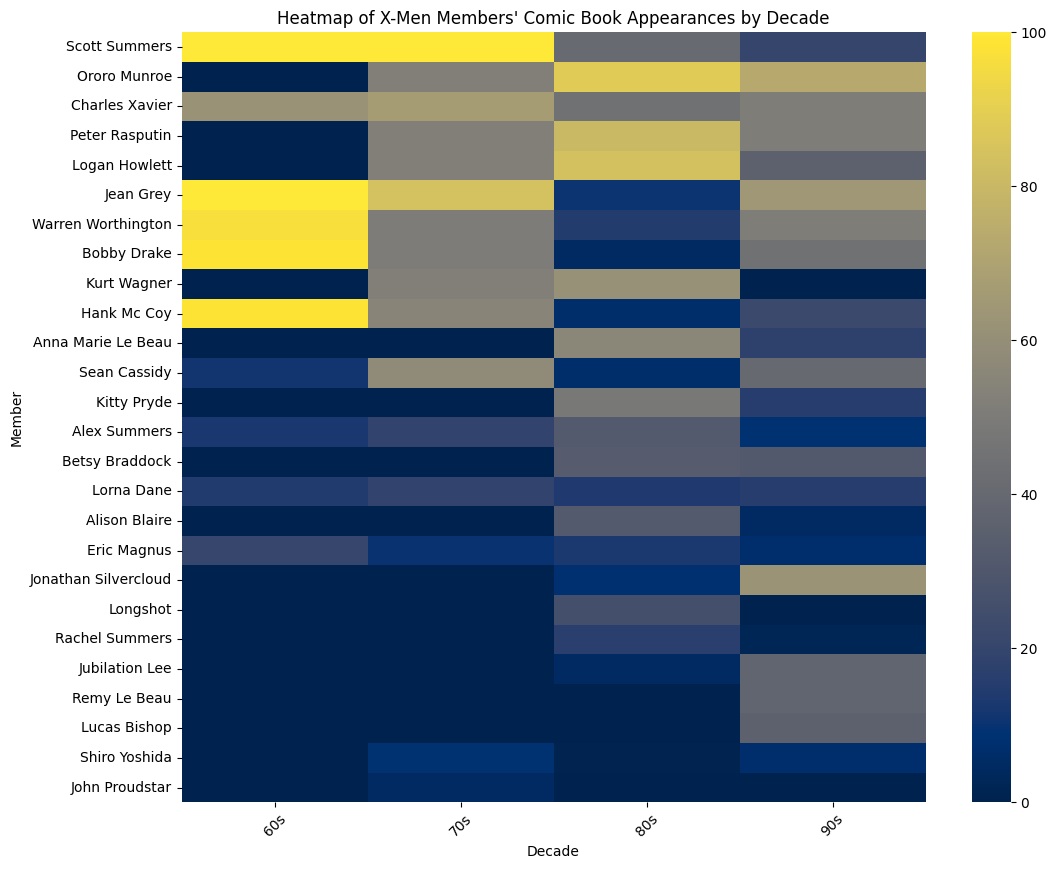

In [10]:
df.sort_values(by='TotalIssues', ascending=False, inplace=True)

decades = ['60s', '70s', '80s', '90s']
issues_columns = ['60s_Appearance_Percent', '70s_Appearance_Percent', '80s_Appearance_Percent', '90s_Appearance_Percent']

# Create a pivot table
pivot_data = df.set_index('Member')[issues_columns]
pivot_data.columns = decades  # Rename columns to decades for readability

# Generate the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_data, cmap="cividis", annot=False, cbar=True)
plt.title('Heatmap of X-Men Members\' Comic Book Appearances by Decade')
plt.xlabel('Decade')
plt.ylabel('Member')
plt.xticks(rotation=45)
plt.show()

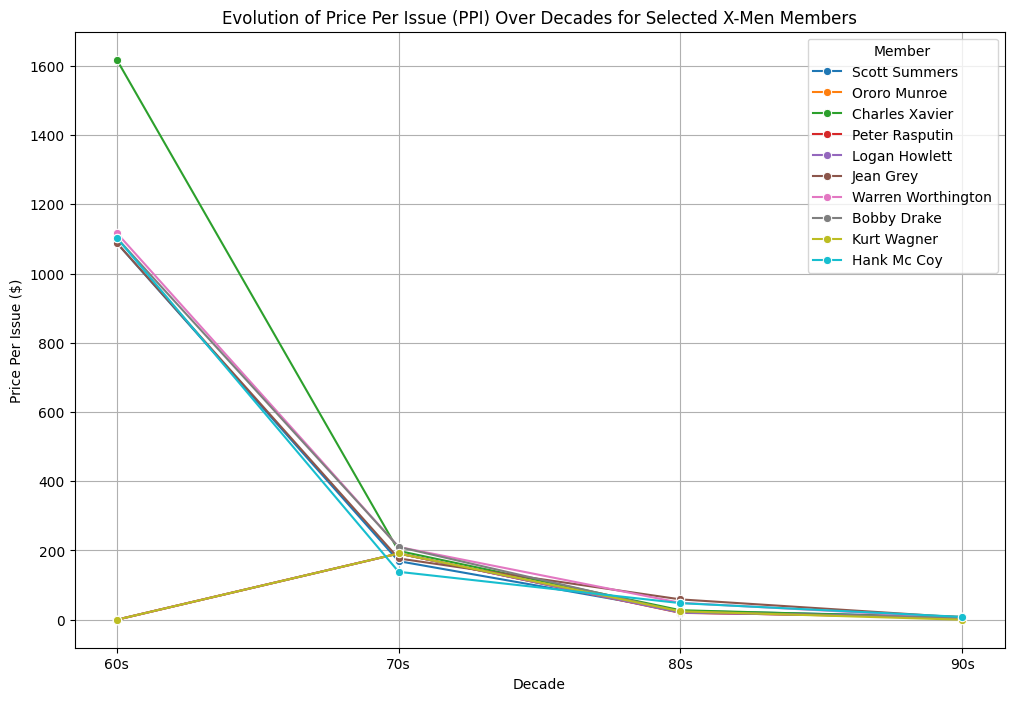

In [17]:
# Let's create a line chart showing the evolution of comic book prices over time for a selection of X-Men characters.
# We'll use the PPI (Price Per Issue) as a proxy for prices over time.
data = df.copy()
# First, let's select a few X-Men characters for clarity in visualization.
# We'll focus on the first five members listed for simplicity.
selected_members = data['Member'].head(10).values

# Creating a dataframe for plotting
time_periods = ['60s', '70s', '80s', '90s']
suffix = '_oStreet'
ppi_columns = ['PPI60s'+suffix, 'PPI70s'+suffix, 'PPI80s'+suffix, 'PPI90s'+suffix]
ppi_data = data[data['Member'].isin(selected_members)][['Member'] + ppi_columns]

# Convert PPI columns to numeric values, removing the '$' and ','
for col in ppi_columns:
    ppi_data[col] = ppi_data[col].replace('[\$,]', '', regex=True).astype(float)

# Reshape the dataframe for plotting
ppi_data_melted = ppi_data.melt(id_vars=["Member"], value_vars=ppi_columns, var_name="Decade", value_name="PPI")

# Replace the column names for decades in 'Decade' column
ppi_data_melted['Decade'] = ppi_data_melted['Decade'].str.replace('PPI', '').str.replace(suffix, '')

# Plotting
plt.figure(figsize=(12, 8))
sns.lineplot(data=ppi_data_melted, x='Decade', y='PPI', hue='Member', marker='o')
plt.title('Evolution of Price Per Issue (PPI) Over Decades for Selected X-Men Members')
plt.xlabel('Decade')
plt.ylabel('Price Per Issue ($)')
plt.legend(title='Member')
plt.grid(True)
plt.show()


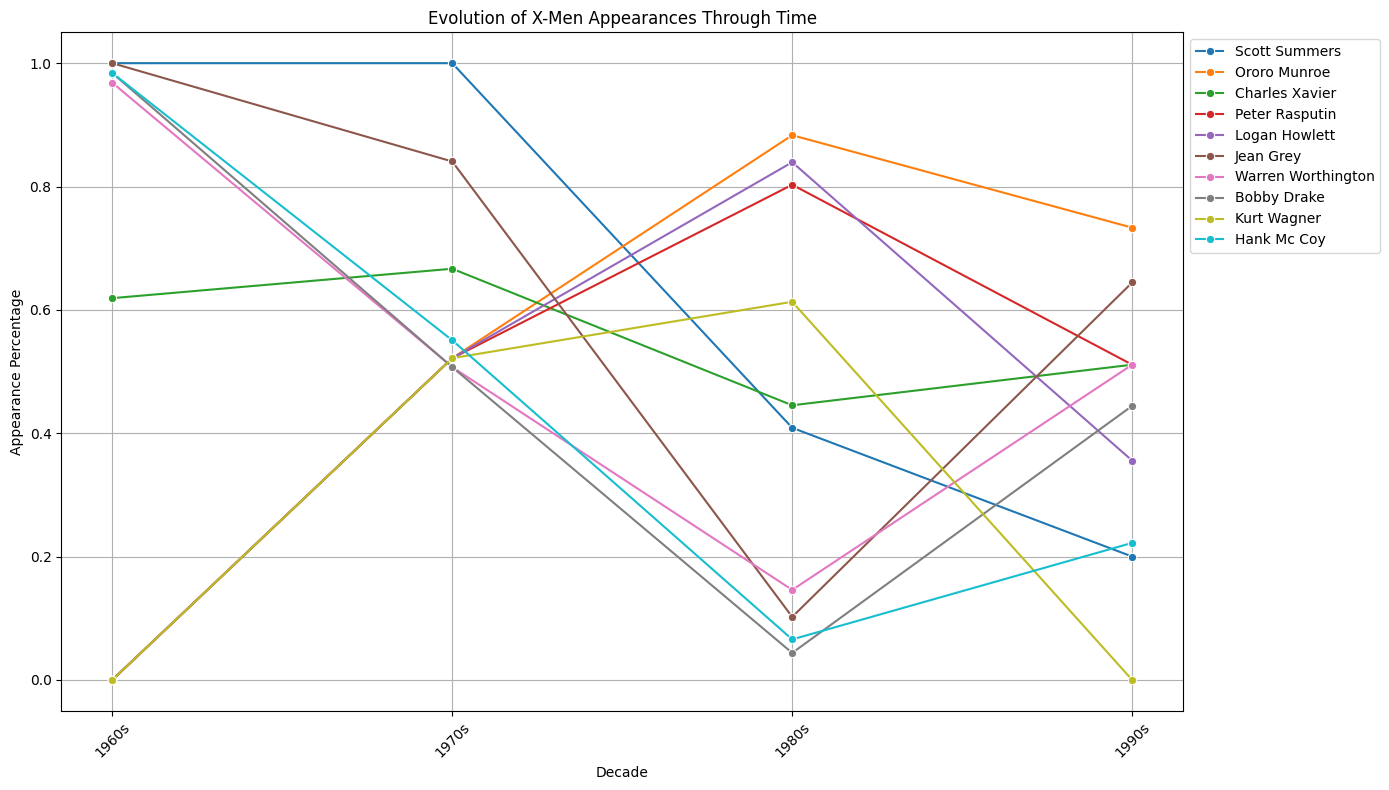

In [18]:
selected_members = data['Member'].head(10).values

# Data preparation for the appearances through time
appearance_cols = ['Member', '60s_Appearance_Percent', '70s_Appearance_Percent', '80s_Appearance_Percent', '90s_Appearance_Percent']
appearance_data = data[appearance_cols].copy()

# Convert percentage strings to floats
for col in appearance_cols[1:]:  # Skip the first column which is 'Member'
    appearance_data[col] = appearance_data[col].str.rstrip('%').astype(float) / 100

# Melting the dataframe for plotting
appearance_data_melted = pd.melt(appearance_data, id_vars=['Member'], value_vars=['60s_Appearance_Percent', '70s_Appearance_Percent', '80s_Appearance_Percent', '90s_Appearance_Percent'],
                                 var_name='Decade', value_name='Appearance_Percent')

# Renaming decades for clarity
appearance_data_melted['Decade'] = appearance_data_melted['Decade'].replace({'60s_Appearance_Percent': '1960s', '70s_Appearance_Percent': '1970s', '80s_Appearance_Percent': '1980s', '90s_Appearance_Percent': '1990s'})

# filtering the data for selected members
appearance_data_melted = appearance_data_melted[appearance_data_melted['Member'].isin(selected_members)]

# Plotting the evolution of appearance percentage through time
plt.figure(figsize=(14, 8))
sns.lineplot(data=appearance_data_melted, x='Decade', y='Appearance_Percent', hue='Member', marker='o')
plt.title('Evolution of X-Men Appearances Through Time')
plt.ylabel('Appearance Percentage')
plt.xlabel('Decade')
plt.xticks(rotation=45)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()

plt.show()


In [19]:
import plotly.graph_objects as go

# Assuming appearance_data_melted is prepared with the necessary data

fig = go.Figure()

# Add a trace for each member
members = appearance_data_melted['Member'].unique()
for member in members:
    member_data = appearance_data_melted[appearance_data_melted['Member'] == member]
    fig.add_trace(go.Scatter(x=member_data['Decade'], y=member_data['Appearance_Percent'],
                             mode='lines+markers', name=member,
                             hoverinfo='name+x+y',  # Customize hover info
                             line=dict(width=3),  # Make lines thicker
                             marker=dict(size=8)))  # Increase marker size for visibility

# Update the layout for better readability and interactivity
fig.update_layout(
    title='Evolution of X-Men Appearances Through Time (Interactive)',
    xaxis_title='Decade',
    yaxis_title='Appearance Percentage',
    legend_title='Member',
    xaxis=dict(tickangle=45),
    width=1400,  # Increase figure width
    height=800,  # Increase figure height
    hovermode='closest',  # Update hovermode
    font=dict(family="Arial, sans-serif",  # Change global font settings
              size=12,
              color="RebeccaPurple"),
    plot_bgcolor='white',  # Set plot background to white
    paper_bgcolor='white',  # Set figure background to light grey
)

fig.show()

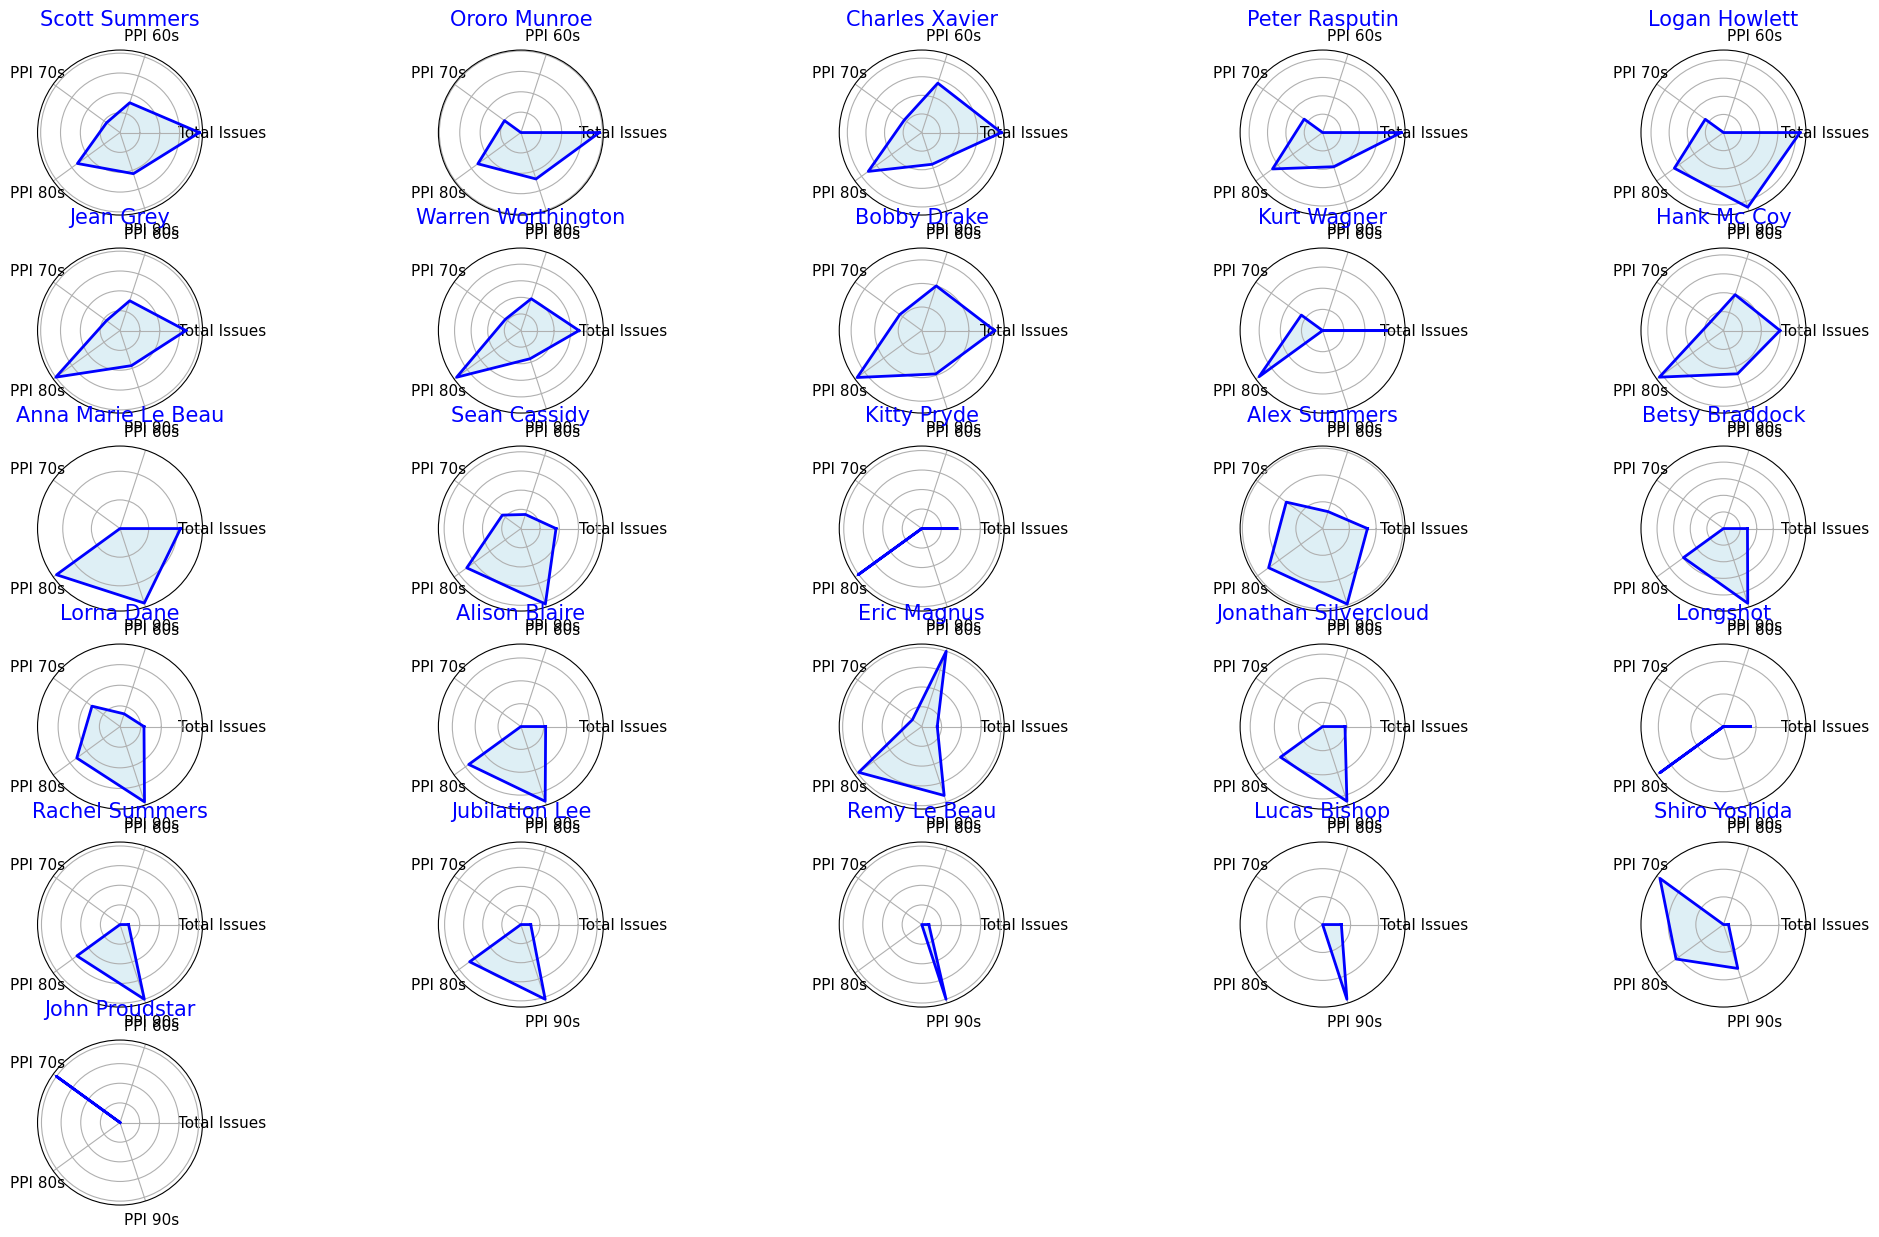

In [115]:
from math import pi
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assumons que `df` est votre DataFrame chargé et préparé
data = df.copy()  # Remplacer par le nom correct de votre DataFrame

features = ['TotalIssues', 'TotalValue_heritage', 'PPI60s_wiz', 'PPI70s_wiz', 'PPI80s_wiz', 'PPI90s_wiz']
features = ['TotalIssues', 'PPI60s_wiz', 'PPI70s_wiz', 'PPI80s_wiz', 'PPI90s_wiz']
features_display = ['Total Issues', 'Total Value ($)', 'PPI 60s', 'PPI 70s', 'PPI 80s', 'PPI 90s']
features_display = ['Total Issues', 'PPI 60s', 'PPI 70s', 'PPI 80s', 'PPI 90s']

# Normalisation des données pour la comparaison
data_normalized = data.copy()
for feature in features[1:]:
    data_normalized[feature] = pd.to_numeric(data_normalized[feature].replace('[\$,]', '', regex=True), errors='coerce')
data_normalized[features] = (data_normalized[features] - data_normalized[features].min()) / (data_normalized[features].max() - data_normalized[features].min())

num_vars = len(features)
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

# Préparation pour les graphiques radar des n X-Men les plus importants
n = 26
n_rows = 6
n_cols = 5
top_n_members = data.nlargest(n, 'TotalIssues')['Member'].values

# Configuration de la grille de sous-graphiques
fig, axs = plt.subplots(figsize=(25, 15), nrows=n_rows, ncols=n_cols, subplot_kw=dict(polar=True))
#fig.subplots_adjust(hspace=0.3, wspace=0.6)

# Boucle pour créer un graphique radar pour chaque membre
for i, ax in enumerate(axs.flatten()):
    if i < len(top_n_members):
        member = top_n_members[i]
        values = data_normalized.loc[data['Member'] == member, features].values.flatten().tolist()
        values += values[:1]
        
        ax.plot(angles, values, color='blue', linewidth=2, linestyle='solid')
        ax.fill(angles, values, color='lightblue', alpha=0.4)
        ax.set_title(member, size=15, color='blue', y=1.1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(features_display, size=11)
        ax.set_yticklabels([])
    else:
        ax.set_axis_off()

fig.savefig('../../radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

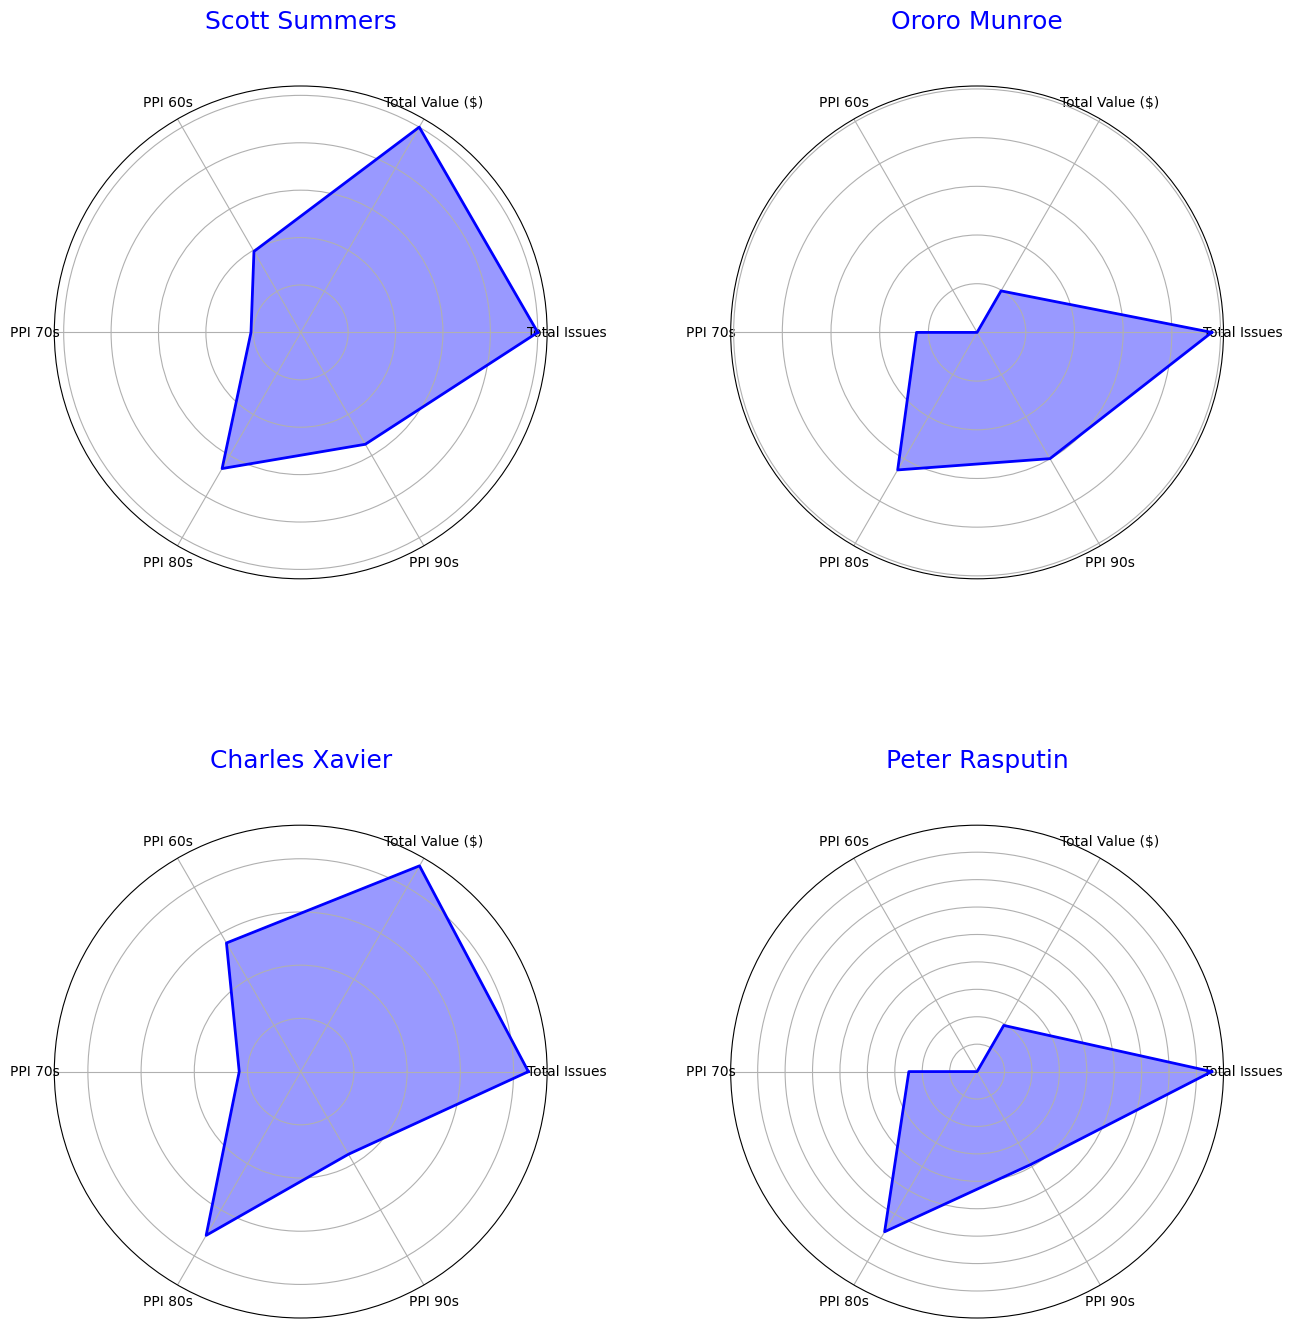

In [72]:
from math import pi

features = ['TotalIssues', 'TotalValue_heritage', 'PPI60s_wiz', 'PPI70s_wiz', 'PPI80s_wiz', 'PPI90s_wiz']
features_display = ['Total Issues', 'Total Value ($)', 'PPI 60s', 'PPI 70s', 'PPI 80s', 'PPI 90s']

# Normalize the features for better comparison
# Note: Direct comparison might not be meaningful due to different scales, but this is for demonstration
data_normalized = df.copy()
for feature in features[1:]:  # Skipping 'TotalIssues' as it's a count, but converting monetary values to float
    data_normalized[feature] = pd.to_numeric(data_normalized[feature].replace('[\$,]', '', regex=True), errors='coerce')
data_normalized[features] = (data_normalized[features] - data_normalized[features].min()) / (data_normalized[features].max() - data_normalized[features].min())

# Number of variables we're plotting.
num_vars = len(features)

# Split the circle into even parts and save the angles so we know where to put each axis.
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

# Preparation for the radar charts for the top 4 X-Men with the most issues
top_4_members = data.nlargest(4, 'TotalIssues')['Member'].values

# Set up the subplot grid
fig, axs = plt.subplots(figsize=(16, 16), nrows=2, ncols=2, subplot_kw=dict(polar=True))
fig.subplots_adjust(hspace=0.5)

# Loop through the top 4 members and create a radar chart for each
for i, ax in enumerate(axs.flatten()):
    member = top_4_members[i]
    values = data_normalized.loc[data['Member'] == member, features].values.flatten().tolist()
    values += values[:1]  # Ensure the plot is closed
    
    # Plot
    ax.plot(angles, values, color='blue', linewidth=2, linestyle='solid')
    ax.fill(angles, values, color='blue', alpha=0.4)
    
    # Decorate
    ax.set_title(member, size=18, color='blue', y=1.1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features_display)
    ax.set_yticklabels([])

plt.show()
